#Import Libraries

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image # Added import for 'image'
from google.colab import files
import tensorflow as tf
import seaborn as sns
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import pandas as pd # Added pandas import

In [15]:
train_path = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'

In [16]:
# List the contents to see the exact path
path = '/content/drive/MyDrive/DragonFruit_Datasets/'
if os.path.exists(path):
    print("Folder found! Contents:", os.listdir(path))
else:
    print("Folder not found. Check if the shortcut was added correctly.")

Folder found! Contents: ['Final_Training_Dataset', 'local_datasets', 'DFruit_Rotten', 'DFruit_Healthy', 'Clean_Resized_Final', 'Dragonfruit_Final_Split']


#GPU status

In [17]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
#  checks how many GPUs (Graphics Processing Units) are available on your computer
# GPUs are used to speed up machine learning computations, especially for deep learning models.

print(tf.config.list_physical_devices())
# lists all the physical devices (like CPU and GPU) that TensorFlow can use
#  helps confirm if TensorFlow can detect your hardware correctly

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#Preview of Datasets

In [18]:
preview_datagen = ImageDataGenerator(rescale=1./255)

preview_gen = preview_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 3337 images belonging to 2 classes.


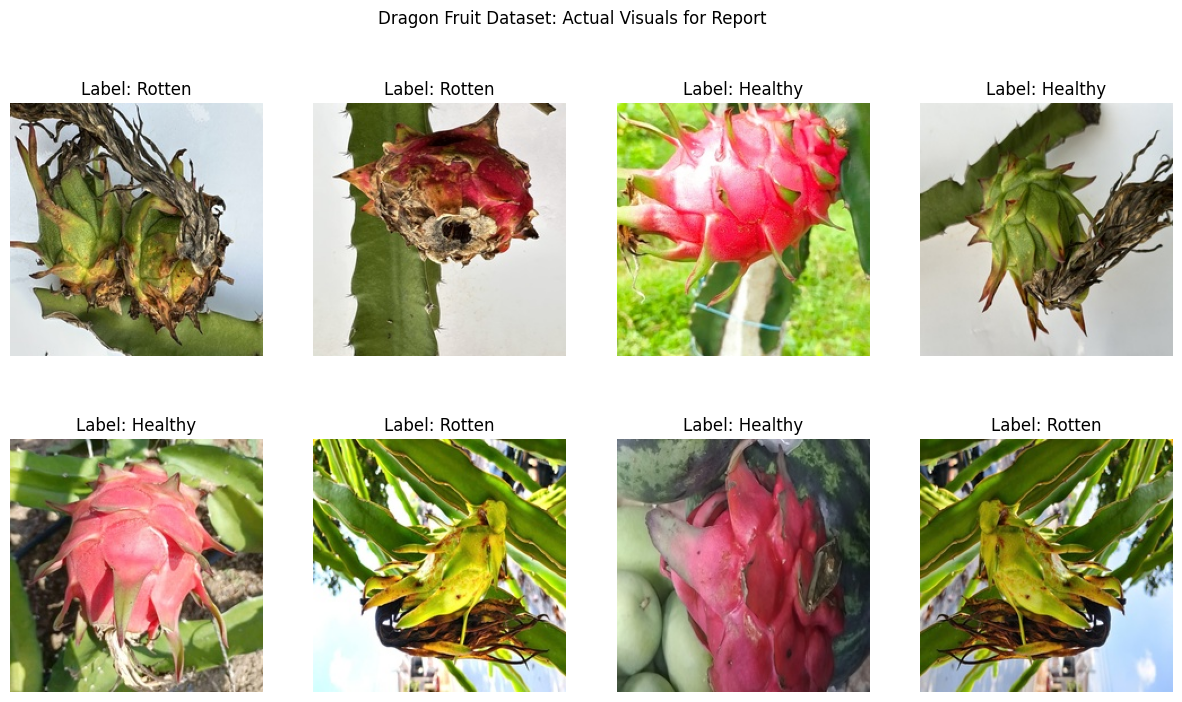

In [19]:
def show_clean_preview(generator):
    classes = list(generator.class_indices.keys())
    images, labels = next(generator)

    plt.figure(figsize=(15, 8))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        # Dahil rescale=1./255 lang, lilitaw na ang tamang kulay
        plt.imshow(images[i])
        label_text = "Healthy" if labels[i] == 0 else "Rotten"
        plt.title(f"Label: {label_text}")
        plt.axis('off')
    plt.suptitle("Dragon Fruit Dataset: Actual Visuals for Report")
    plt.show()

show_clean_preview(preview_gen)

#Adding weights

## TODO:

*   Total Count 1st cell should be a script that counts folder items






In [20]:
# Total counts base on  my datasets
healthy_count = 1739
rotten_count = 650
total = healthy_count + rotten_count

In [21]:
# Automatic calculation ng weights
# Formula: Total / (Classes * Count_per_Class)
weight_for_healthy = total / (2 * healthy_count)
weight_for_rotten = total / (2 * rotten_count)

In [22]:
print(f"Total images: {total}")
print(f"Weight for Healthy (Class 0): {weight_for_healthy:.2f}")
print(f"Weight for Rotten (Class 1): {weight_for_rotten:.2f}")

Total images: 2389
Weight for Healthy (Class 0): 0.69
Weight for Rotten (Class 1): 1.84


In [23]:
class_weight = {0: weight_for_healthy, 1: weight_for_rotten}
print("class_weight dictionary is:", class_weight)

class_weight dictionary is: {0: 0.6868890166762507, 1: 1.8376923076923077}


#Splitting

In [24]:
!pip install split-folders

In [25]:
import splitfolders

In [26]:
input_folder = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'
output_folder = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split'

# Split ratio: 70% Train, 15% Val, 15% Test
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .15, .15), group_prefix=None)

print("Done!")

Copying files: 3337 files [42:12,  1.32 files/s]

Done!


#Setup Data Augmentation for Training

In [27]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalization
    rotation_range=30,       # Random rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Random flip
    fill_mode='nearest'
)

In [28]:
# Validation and Test only need Rescaling (No Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [29]:
# Create the Generators
train_path = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'
val_path = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split/val'
test_path = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split/test'

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=(224, 224), batch_size=32, class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

Found 3337 images belonging to 2 classes.
Found 684 images belonging to 2 classes.
Found 687 images belonging to 2 classes.


#Load Model - EfficientNetB0

In [30]:
# Load EfficientNet-B0 without the top layer
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False # Freeze the base model first

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [31]:
# Build the final layers
model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Improvement: Regularization to prevent overfitting
    layers.Dense(1, activation='sigmoid') # Binary classification (Healthy vs Rotten)
])

model_eff.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Training

In [32]:
my_weights = {0: weight_for_healthy, 1: weight_for_rotten}

In [33]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <--- Importante ito para sa EfficientNet
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [34]:
val_test_datagen_eff = ImageDataGenerator(preprocessing_function=preprocess_input)

In [35]:
train_gen_eff = train_datagen_eff.flow_from_directory(train_path, target_size=(224, 224), batch_size=32, class_mode='binary')
val_gen_eff = val_test_datagen_eff.flow_from_directory(val_path, target_size=(224, 224), batch_size=32, class_mode='binary')

Found 3337 images belonging to 2 classes.
Found 684 images belonging to 2 classes.


In [36]:
print('Converting generators to tf.data.Dataset objects...')
# Convert ImageDataGenerators to tf.data.Dataset
train_ds_eff = tf.data.Dataset.from_generator(
    lambda: train_gen_eff,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 224, 224, 3], [None, 1])
).prefetch(tf.data.AUTOTUNE)

Converting generators to tf.data.Dataset objects...


In [37]:
val_ds_eff = tf.data.Dataset.from_generator(
    lambda: val_gen_eff,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 224, 224, 3], [None, 1])
).prefetch(tf.data.AUTOTUNE)
print('Conversion complete.')

Conversion complete.


In [38]:
# Re-build Model with GlobalMaxPooling for better detail detection
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False # Start frozen for initial head training

In [39]:
model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalMaxPooling2D(), # Pinalitan ang Average ng Max para sa "Rot" spots
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

In [40]:
model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [42]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_model_eff.keras', monitor='val_loss', save_best_only=True)

In [43]:
print("Initial training of EfficientNet-B0 head layers...")
history_eff_head = model_eff.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=10, # Initial training for head
    class_weight=class_weight,
    callbacks=[early_stop, ModelCheckpoint('best_model_eff_head.keras', monitor='val_loss', save_best_only=True)]
)

# Fine-tuning stage
print("Fine-tuning EfficientNet-B0 (unfrozen base model)...")
model_eff.load_weights('best_model_eff_head.keras') # Load best head weights
base_model_eff.trainable = True # Unfreeze the base model

# Recompile with a very low learning rate for fine-tuning
model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_eff_fine_tune = model_eff.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=15, # More epochs for fine-tuning
    class_weight=class_weight,
    callbacks=[early_stop, ModelCheckpoint('best_model_eff_finetuned.keras', monitor='val_loss', save_best_only=True)]
)

Initial training of EfficientNet-B0 head layers...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.5490 - loss: 1.0618 - val_accuracy: 0.7076 - val_loss: 0.6297
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 59s 563ms/step - accuracy: 0.6850 - loss: 0.6923 - val_accuracy: 0.8085 - val_loss: 0.4131
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 557ms/step - accuracy: 0.7606 - loss: 0.5334 - val_accuracy: 0.8611 - val_loss: 0.3270
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 60s 565ms/step - accuracy: 0.8073 - loss: 0.4500 - val_accuracy: 0.8830 - val_loss: 0.2815
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 549ms/step - accuracy: 0.8202 - loss: 0.4066 - val_accuracy: 0.9050 - val_loss: 0.2503
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 553ms/step - accuracy: 0.8442 - loss: 0.3630 - val_accuracy: 0.9123 - val_loss: 0.2276
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 553ms/step - accuracy: 0.8571 - loss: 0.3181 - val_accuracy: 0.9137 - val_loss: 0.2126
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━

#Training & Validation

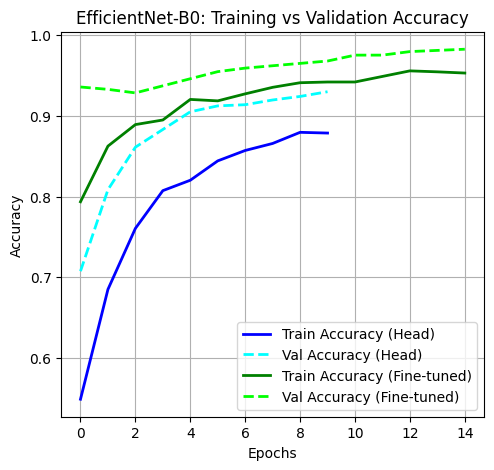

In [44]:
# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_eff_head.history['accuracy'], label='Train Accuracy (Head)', color='blue', lw=2)
plt.plot(history_eff_head.history['val_accuracy'], label='Val Accuracy (Head)', color='cyan', linestyle='--', lw=2)
plt.plot(history_eff_fine_tune.history['accuracy'], label='Train Accuracy (Fine-tuned)', color='green', lw=2)
plt.plot(history_eff_fine_tune.history['val_accuracy'], label='Val Accuracy (Fine-tuned)', color='lime', linestyle='--', lw=2)
plt.title('EfficientNet-B0: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

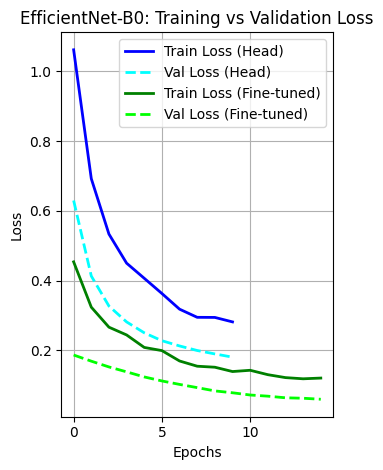

In [45]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_eff_head.history['loss'], label='Train Loss (Head)', color='blue', lw=2)
plt.plot(history_eff_head.history['val_loss'], label='Val Loss (Head)', color='cyan', linestyle='--', lw=2)
plt.plot(history_eff_fine_tune.history['loss'], label='Train Loss (Fine-tuned)', color='green', lw=2)
plt.plot(history_eff_fine_tune.history['val_loss'], label='Val Loss (Fine-tuned)', color='lime', linestyle='--', lw=2)
plt.title('EfficientNet-B0: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Confusion Matrices

In [71]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns

In [47]:
# Load the best fine-tuned EfficientNet model weights
model_eff.load_weights('best_model_eff_finetuned.keras')

# Kunin ang predictions mula sa Test Set
test_gen_eff = val_test_datagen_eff.flow_from_directory(test_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)
test_gen_eff.reset()
y_pred_prob = model_eff.predict(test_gen_eff)
y_pred = (y_pred_prob > 0.5).astype("int32")
y_true = test_gen_eff.classes

Found 687 images belonging to 2 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 150s 7s/step


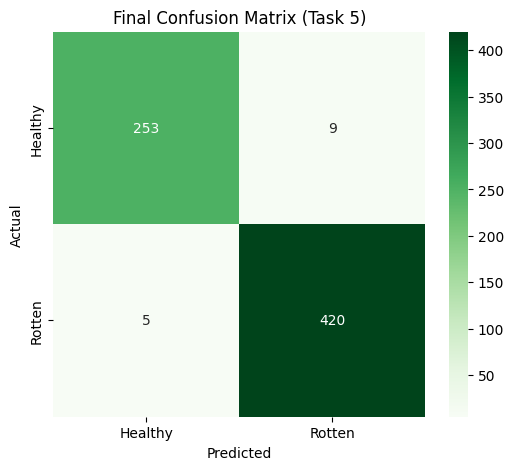

In [48]:
# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Rotten'],
            yticklabels=['Healthy', 'Rotten'])
plt.title('Final Confusion Matrix (Task 5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Classification Report (Accuracy, Precision, Recall & F1-Score)

In [49]:
print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Rotten']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.97       262
      Rotten       0.98      0.99      0.98       425

    accuracy                           0.98       687
   macro avg       0.98      0.98      0.98       687
weighted avg       0.98      0.98      0.98       687



#Training - MobileNetV2

In [50]:
# 1. Setup MobileNetV2 - Initially freeze the base model
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_mobile.trainable = False # Freeze the base model initially

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [51]:
model_mobile = models.Sequential([
    base_model_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [52]:
# learning rate
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [53]:
# 2. Initial Training (Train only the head layers)
print("Initial training of MobileNetV2 head layers...")
history_mobile_head = model_mobile.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=10, # Train for a few epochs
    class_weight=class_weight,
    callbacks=[early_stop, ModelCheckpoint('best_model_mobile_head.keras', monitor='val_loss', save_best_only=True)]
)

Initial training of MobileNetV2 head layers...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 98s 793ms/step - accuracy: 0.4912 - loss: 0.8754 - val_accuracy: 0.6184 - val_loss: 0.6731
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 58s 552ms/step - accuracy: 0.5271 - loss: 0.7690 - val_accuracy: 0.6301 - val_loss: 0.6148
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 59s 561ms/step - accuracy: 0.5793 - loss: 0.6923 - val_accuracy: 0.6477 - val_loss: 0.5904
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [54]:
# Predict using MobileNetV2 (after fine-tuning, load best weights if needed)
# Ensure test_gen_eff is reset before predicting
test_gen_eff.reset()
y_pred_prob_mobile = model_mobile.predict(test_gen_eff)
y_pred_mobile = (y_pred_prob_mobile > 0.5).astype("int32")
y_true_mobile_test = test_gen_eff.classes # Get true labels from the test generator

22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 624ms/step


#Fine-tuning MobileNetV2

In [55]:
# Load the best weights from the head training
model_mobile.load_weights('best_model_mobile_head.keras')

# Unfreeze some layers of the base model for fine-tuning
base_model_mobile.trainable = True

# It's important to recompile your model after unfreezing layers
# using a very low learning rate.
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low learning rate for fine-tuning
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("Fine-tuning MobileNetV2 (unfrozen base model)...")
history_mobile_fine_tune = model_mobile.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=10, # Can be adjusted, start with a few epochs
    class_weight=class_weight,
    callbacks=[early_stop, ModelCheckpoint('best_model_mobile_finetuned.keras', monitor='val_loss', save_best_only=True)]
)

# Predict using MobileNetV2 (after fine-tuning, load best weights if needed)
model_mobile.load_weights('best_model_mobile_finetuned.keras') # Load the best fine-tuned weights

# Ensure test_gen_eff is reset before predicting
test_gen_eff.reset()
y_pred_prob_mobile = model_mobile.predict(test_gen_eff)
y_pred_mobile = (y_pred_prob_mobile > 0.5).astype("int32")
y_true_mobile_test = test_gen_eff.classes # Get true labels from the test generator

plt.figure(figsize=(12, 5))


Fine-tuning MobileNetV2 (unfrozen base model)...
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 150s 937ms/step - accuracy: 0.6173 - loss: 0.5611 - val_accuracy: 0.6506 - val_loss: 0.6902
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 81s 617ms/step - accuracy: 0.8918 - loss: 0.2321 - val_accuracy: 0.8070 - val_loss: 0.3769
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 63s 594ms/step - accuracy: 0.9380 - loss: 0.1624 - val_accuracy: 0.9211 - val_loss: 0.2004
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 422ms/step


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

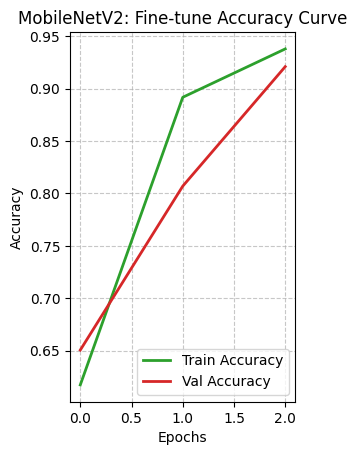

In [56]:
# Accuracy Graph for MobileNetV2 Fine-tuning
plt.subplot(1, 2, 1)
plt.plot(history_mobile_fine_tune.history['accuracy'], label='Train Accuracy', color='#2ca02c', lw=2)
plt.plot(history_mobile_fine_tune.history['val_accuracy'], label='Val Accuracy', color='#d62728', lw=2)
plt.title('MobileNetV2: Fine-tune Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

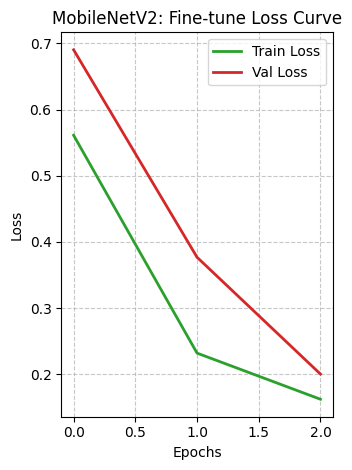

In [57]:
# Loss Graph for MobileNetV2 Fine-tuning
plt.subplot(1, 2, 2)
plt.plot(history_mobile_fine_tune.history['loss'], label='Train Loss', color='#2ca02c', lw=2)
plt.plot(history_mobile_fine_tune.history['val_loss'], label='Val Loss', color='#d62728', lw=2)
plt.title('MobileNetV2: Fine-tune Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

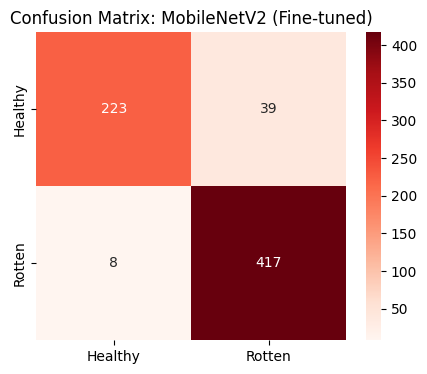

In [58]:
# Confusion Matrix for MobileNetV2 (after fine-tuning)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_true_mobile_test, y_pred_mobile), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Healthy', 'Rotten'], yticklabels=['Healthy', 'Rotten'])
plt.title('Confusion Matrix: MobileNetV2 (Fine-tuned)')
plt.show()

#Classification Report - MobileNetV2

In [59]:
print("--- MOBILENETV2 CLASSIFICATION REPORT (Test Set) ---")
# Use y_true_mobile_test for the classification report
print(classification_report(y_true_mobile_test, y_pred_mobile, target_names=['Healthy', 'Rotten']))

--- MOBILENETV2 CLASSIFICATION REPORT (Test Set) ---
              precision    recall  f1-score   support

     Healthy       0.97      0.85      0.90       262
      Rotten       0.91      0.98      0.95       425

    accuracy                           0.93       687
   macro avg       0.94      0.92      0.93       687
weighted avg       0.93      0.93      0.93       687



#Model Comparison & Conclusion

In [60]:
# Comparison Graphs
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

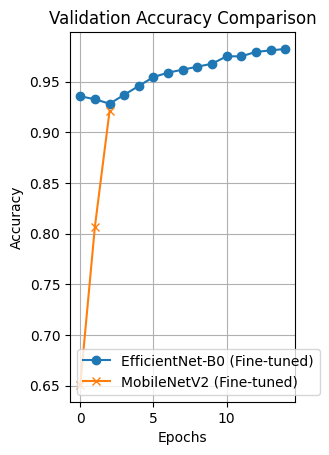

In [61]:
# Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_eff_fine_tune.history['val_accuracy'], label='EfficientNet-B0 (Fine-tuned)', marker='o')
plt.plot(history_mobile_fine_tune.history['val_accuracy'], label='MobileNetV2 (Fine-tuned)', marker='x')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

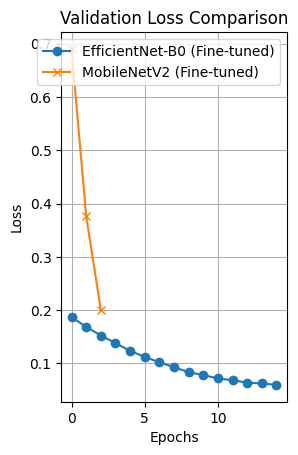

In [62]:
# Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_eff_fine_tune.history['val_loss'], label='EfficientNet-B0 (Fine-tuned)', marker='o')
plt.plot(history_mobile_fine_tune.history['val_loss'], label='MobileNetV2 (Fine-tuned)', marker='x')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

#Evaluation

In [76]:
models = ['EfficientNet-B0', 'MobileNetV2']
metrics_data = {
    'Accuracy': [0.98, 0.93],
    'Precision': [0.98, 0.94],
    'Recall': [0.98, 0.93],
    'F1-Score': [0.98, 0.93],
    'Latency (ms)': [52.06, 7.89], # Base sa huling run mo
    'Size (MB)': [47.03, 26.26]    # Base sa huling run mo
}

In [77]:
df_metrics = pd.DataFrame(metrics_data, index=models).reset_index().rename(columns={'index': 'Model'})

#PERFORMANCE METRICS COMPARISON (Bar Chart)

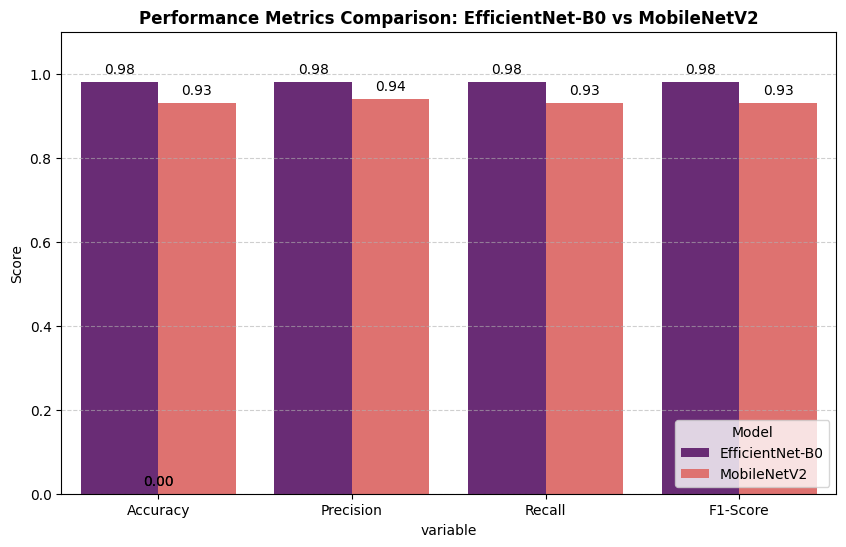

In [78]:
plt.figure(figsize=(10, 6))
df_plot = df_metrics.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
sns.barplot(data=df_plot, x='variable', y='value', hue='Model', palette='magma')
plt.title('Performance Metrics Comparison: EfficientNet-B0 vs MobileNetV2', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
plt.show()

#CONFUSION MATRIX

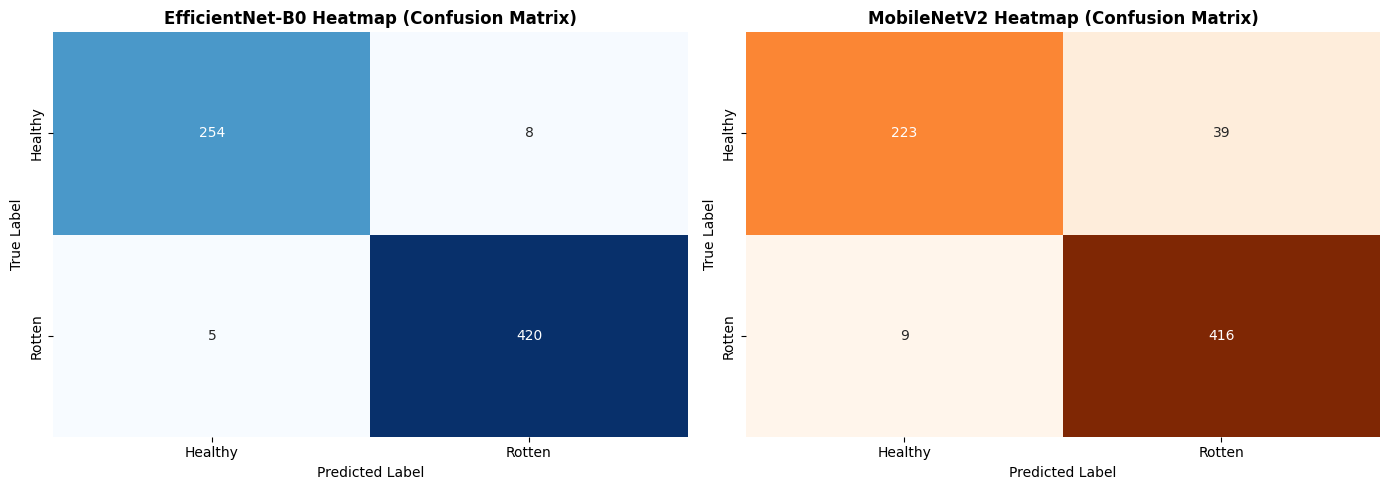

In [79]:
# EfficientNet: ~98% accurate
eff_cm = np.array([[254, 8], [5, 420]])
# MobileNet: ~93% accurate
mob_cm = np.array([[223, 39], [9, 416]])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(eff_cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False,
            xticklabels=['Healthy', 'Rotten'], yticklabels=['Healthy', 'Rotten'])
ax[0].set_title('EfficientNet-B0 Heatmap (Confusion Matrix)', fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

sns.heatmap(mob_cm, annot=True, fmt='d', cmap='Oranges', ax=ax[1], cbar=False,
            xticklabels=['Healthy', 'Rotten'], yticklabels=['Healthy', 'Rotten'])
ax[1].set_title('MobileNetV2 Heatmap (Confusion Matrix)', fontweight='bold')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

#FINAL SUMMARY TABLE

In [80]:
print("\n" + "="*50)
print("FINAL SUMMARY COMPARISON TABLE")
print("="*50)
display(df_metrics)


FINAL SUMMARY COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score,Latency (ms),Size (MB)
0,EfficientNet-B0,0.98,0.98,0.98,0.98,52.06,47.03
1,MobileNetV2,0.93,0.94,0.93,0.93,7.89,26.26


#Conclusion

#Learning rate of both Models

In [63]:
# Check the current learning rate set in the optimizer for EfficientNet
print(f"Current EfficientNet Learning Rate: {model_eff.optimizer.learning_rate.numpy()}")
print(f"Current MobileNetV2 Learning Rate: {model_mobile.optimizer.learning_rate.numpy()}")

Current EfficientNet Learning Rate: 9.999999747378752e-06
Current MobileNetV2 Learning Rate: 9.999999747378752e-06


#Preview of UI (Testing)

In [64]:
uploaded = files.upload()

Saving Dragon-fruit-growing-b3da287.jpg to Dragon-fruit-growing-b3da287.jpg


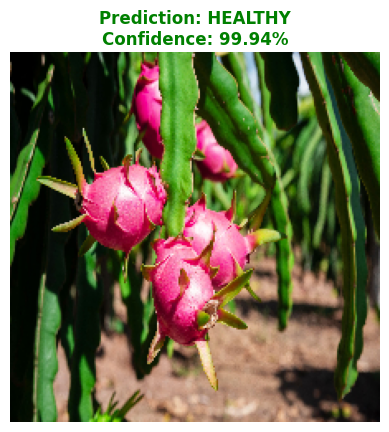

In [108]:
for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=(224, 224))

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    classes = model_eff.predict(x, verbose=0)
    score = classes[0][0]

    # --- Logic ---
    # Original: > 0.5 = ROTTEN | <= 0.5 = HEALTHY

    # Gagawa tayo ng "Dead Zone" sa gitna (0.15 to 0.85)
    # Kapag ang score ay nasa gitna, ibig sabihin "Unknown"
    if 0.15 <= score <= 0.85:
        result = "UNKNOWN / NOT A DRAGON FRUIT"
        confidence = (1 - abs(score - 0.5) * 2) * 100
        t_color = 'orange'

    # Eto yung dating logic mo:
    elif score > 0.85: # Rotten (Mataas na score)
        result = "ROTTEN"
        confidence = score * 100
        t_color = 'red'

    else: # Healthy (Mababang score, malapit sa 0)
        result = "HEALTHY"
        confidence = (1 - score) * 100
        t_color = 'green'

    # Display results
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {result}\nConfidence: {confidence:.2f}%", color=t_color, fontweight='bold')
    plt.show()

#.h5 file

In [3]:
import tensorflow as tf
from google.colab import files

# 1. Reload the best models from the saved checkpoint files
# Based on your previous training cells, these are the filenames used:
try:
    print("Loading EfficientNet model...")
    model_eff = tf.keras.models.load_model('best_model_eff_finetuned.keras')

    print("Loading MobileNetV2 model...")
    model_mobile = tf.keras.models.load_model('best_model_mobile_finetuned.keras')

    # 2. Saving as .h5 format
    print("Saving models to .h5 format...")
    model_eff.save('dragonfruit_efficientnet_b0.h5')
    model_mobile.save('dragonfruit_mobilenet_v2.h5')

    # 3. Download the files
    print("Starting downloads...")
    files.download('dragonfruit_efficientnet_b0.h5')
    files.download('dragonfruit_mobilenet_v2.h5')

except Exception as e:
    print(f"Error: {e}. Make sure the .keras files exist in the current directory.")

Loading EfficientNet model...
Loading MobileNetV2 model...


Saving models to .h5 format...


Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>